# EDA FD002 - condiciones operativas

Objetivo: entender como las seis condiciones operativas de FD002 afectan las mediciones de sensores y la relacion con RUL.

FD002 tiene un solo modo de falla, pero seis regimes operativos. Por eso la pregunta principal es si la baja correlacion global sensor-RUL se debe a mezclar distribuciones de sensores de condiciones distintas.


## 1. Setup


In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "CMAPSSData").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import FEATURE_COLUMNS, SENSOR_COLUMNS, SETTING_COLUMNS, add_train_rul, last_cycle_rows, load_cmapss_subset
from src.eda import correlation_with_target, dataset_overview, train_test_distribution_shift

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 2. Carga de FD002

FD002 combina seis condiciones operativas con un unico modo de falla. A diferencia de FD001, los settings no son ruido: definen regimes que afectan directamente los sensores.


In [6]:
data = load_cmapss_subset("FD002", data_dir=PROJECT_ROOT / "CMAPSSData")
train = add_train_rul(data.train)
test = data.test.copy()
test_last = last_cycle_rows(test).merge(data.rul, on="unit", how="left")

overview = dataset_overview(data.train, data.test, data.rul)
overview


,dataset,rows,columns,units,missing_values,duplicated_rows
0,train,53759,26,260,0,0
1,test,33991,26,259,0,0
2,rul,259,2,259,0,0


In [7]:
setting_summary = train[SETTING_COLUMNS].agg(["mean", "std", "min", "max"]).T
setting_summary


,mean,std,min,max
setting_1,23.9984,14.7474,0.0000,42.0080
setting_2,0.5721,0.3100,0.0000,0.8420
setting_3,94.0460,14.2377,60.0000,100.0000


## 3. Identificacion de las seis conditions

El dataset declara seis condiciones operativas. Se usa clustering no supervisado sobre `setting_1`, `setting_2` y `setting_3` para asignar un `condition_id` reproducible a cada fila.


In [8]:
settings_scaler = StandardScaler()
settings_X = settings_scaler.fit_transform(train[SETTING_COLUMNS])

# El silhouette es costoso en todas las filas; una muestra alcanza para validar k.
settings_sample = train[SETTING_COLUMNS].sample(
    min(12000, len(train)),
    random_state=RANDOM_STATE,
)
settings_sample_X = settings_scaler.transform(settings_sample)

k_rows = []
for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(settings_sample_X)
    k_rows.append({"k": k, "silhouette_sample": silhouette_score(settings_sample_X, labels)})

condition_k_summary = pd.DataFrame(k_rows)
condition_k_summary


,k,silhouette_sample
0,2,0.6190
1,3,0.8010
2,4,0.8512
3,5,0.9304
4,6,0.9971
5,7,0.9331
6,8,0.8987
7,9,0.8629


In [9]:
condition_model = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=50)
train_raw_condition = condition_model.fit_predict(settings_X)

centers = pd.DataFrame(
    settings_scaler.inverse_transform(condition_model.cluster_centers_),
    columns=SETTING_COLUMNS,
)
centers["raw_condition"] = range(len(centers))
centers = centers.sort_values(SETTING_COLUMNS).reset_index(drop=True)
centers["condition_id"] = range(1, len(centers) + 1)
condition_mapping = dict(zip(centers["raw_condition"], centers["condition_id"]))

train_cond = train.copy()
train_cond["condition_id"] = pd.Series(train_raw_condition).map(condition_mapping).to_numpy()

test_raw_condition = condition_model.predict(settings_scaler.transform(test[SETTING_COLUMNS]))
test_cond = test.copy()
test_cond["condition_id"] = pd.Series(test_raw_condition).map(condition_mapping).to_numpy()

test_last_cond = last_cycle_rows(test_cond).merge(data.rul, on="unit", how="left")

centers[["condition_id"] + SETTING_COLUMNS]


,condition_id,setting_1,setting_2,setting_3
0,1,0.0015,0.0005,100.0000
1,2,10.0030,0.2505,100.0000
2,3,20.0030,0.7005,100.0000
3,4,25.0030,0.6205,60.0000
4,5,35.0030,0.8405,100.0000
5,6,42.0030,0.8405,100.0000


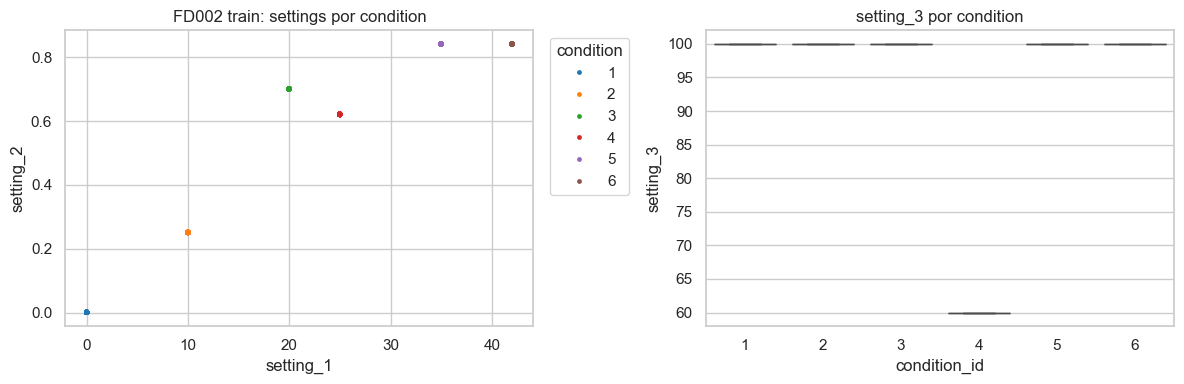

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    data=train_cond.sample(min(12000, len(train_cond)), random_state=RANDOM_STATE),
    x="setting_1",
    y="setting_2",
    hue="condition_id",
    palette="tab10",
    s=12,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("FD002 train: settings por condition")
axes[0].legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(data=train_cond, x="condition_id", y="setting_3", ax=axes[1], showfliers=False)
axes[1].set_title("setting_3 por condition")
axes[1].set_xlabel("condition_id")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_conditions_settings_clusters.png", dpi=150)
plt.show()


## 4. Balance de conditions en train y test

Antes de modelar conviene ver si train y test tienen proporciones similares de conditions. Si no, el modelo puede enfrentar shift operativo.


In [11]:
def condition_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df["condition_id"].value_counts().sort_index()
    result = counts.rename("rows").reset_index().rename(columns={"index": "condition_id"})
    result["condition_id"] = result["condition_id"].astype(int)
    result["row_pct"] = result["rows"] / result["rows"].sum() * 100
    result["units"] = df.groupby("condition_id")["unit"].nunique().reindex(result["condition_id"]).to_numpy()
    result["split"] = split
    return result

condition_dist = pd.concat(
    [
        condition_distribution(train_cond, "train_rows"),
        condition_distribution(test_cond, "test_rows"),
        condition_distribution(test_last_cond, "test_last_cycle"),
    ],
    ignore_index=True,
)
condition_dist


,condition_id,rows,row_pct,units,split
0,1,8044,14.9631,260,train_rows
1,2,8096,15.0598,260,train_rows
2,3,8122,15.1082,260,train_rows
3,4,8002,14.8849,260,train_rows
4,5,8037,14.9501,260,train_rows
5,6,13458,25.0339,260,train_rows
6,1,5148,15.1452,259,test_rows
7,2,5107,15.0246,258,test_rows
8,3,5063,14.8951,259,test_rows
9,4,5042,14.8333,259,test_rows


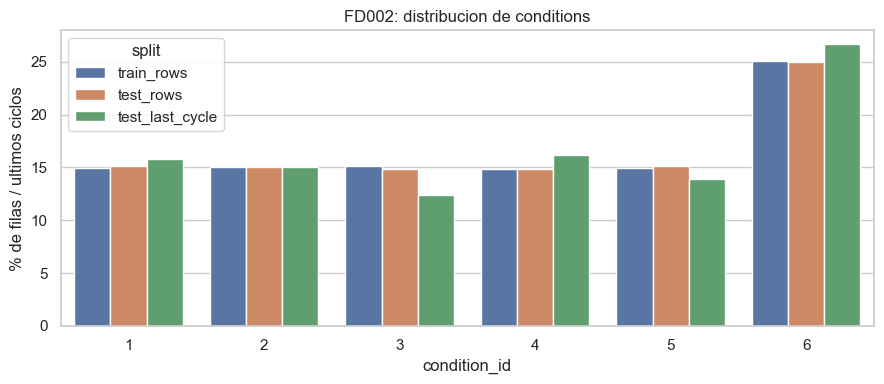

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=condition_dist, x="condition_id", y="row_pct", hue="split", ax=ax)
ax.set_title("FD002: distribucion de conditions")
ax.set_xlabel("condition_id")
ax.set_ylabel("% de filas / ultimos ciclos")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_distribution.png", dpi=150)
plt.show()


In [13]:
unit_condition_counts = train_cond.groupby("unit")["condition_id"].nunique().describe()
unit_condition_counts


count   260.0000
mean      6.0000
std       0.0000
min       6.0000
25%       6.0000
50%       6.0000
75%       6.0000
max       6.0000
Name: condition_id, dtype: float64

## 5. Efecto de condition sobre sensores

Si los sensores cambian mucho entre conditions, una correlacion global sensor-RUL puede ser enganosa: estaria mezclando cambios por degradacion con cambios por regimen operativo.


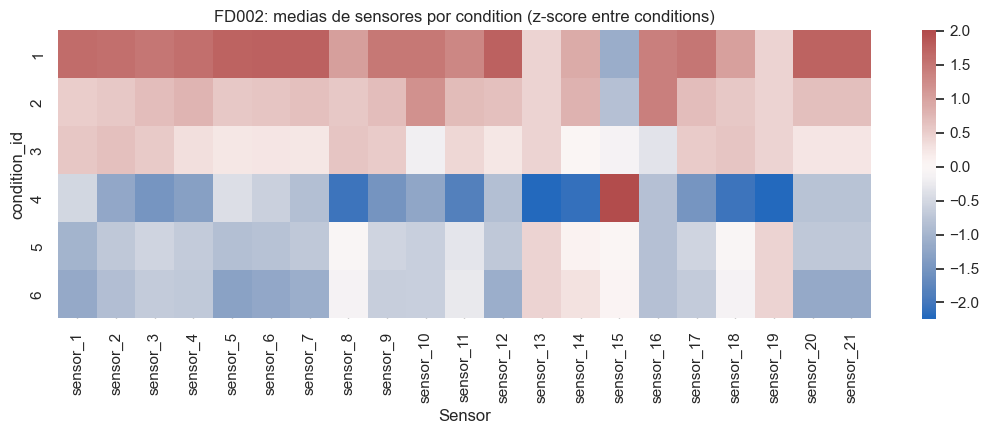

In [14]:
condition_sensor_means = train_cond.groupby("condition_id")[SENSOR_COLUMNS].mean()
condition_sensor_means_z = (condition_sensor_means - condition_sensor_means.mean()) / condition_sensor_means.std(ddof=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(condition_sensor_means_z, cmap="vlag", center=0, ax=ax)
ax.set_title("FD002: medias de sensores por condition (z-score entre conditions)")
ax.set_xlabel("Sensor")
ax.set_ylabel("condition_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_sensor_means_by_condition_heatmap.png", dpi=150)
plt.show()


In [15]:
pooled_sensor_std = train_cond[SENSOR_COLUMNS].std()
condition_sensor_effect = (
    (condition_sensor_means.max() - condition_sensor_means.min()) / pooled_sensor_std
).sort_values(ascending=False)
condition_sensor_effect.head(12).rename("condition_range_over_global_std").to_frame()


,condition_range_over_global_std
sensor_11,3.3228
sensor_15,3.2985
sensor_8,3.2552
sensor_18,3.2547
sensor_9,3.1188
sensor_14,3.1024
sensor_3,3.0934
sensor_17,3.0932
sensor_4,3.0098
sensor_5,2.9636


## 6. Correlacion sensor-RUL global vs dentro de condition

Se compara la correlacion global con la correlacion calculada por condition. Si dentro de conditions aparecen relaciones mas fuertes, entonces las conditions estaban ocultando parte de la senal.


In [16]:
global_corr = correlation_with_target(train_cond, target="RUL", columns=SENSOR_COLUMNS)

def corr_by_condition(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for condition_id, group in df.groupby("condition_id"):
        corr = correlation_with_target(group, target="RUL", columns=SENSOR_COLUMNS)
        for sensor, row in corr.iterrows():
            rows.append(
                {
                    "condition_id": condition_id,
                    "sensor": sensor,
                    "correlation": row["correlation"],
                    "abs_correlation": row["abs_correlation"],
                }
            )
    return pd.DataFrame(rows)

condition_corr = corr_by_condition(train_cond)
condition_corr_summary = (
    condition_corr.groupby("sensor")
    .agg(
        mean_abs_corr_by_condition=("abs_correlation", "mean"),
        max_abs_corr_by_condition=("abs_correlation", "max"),
    )
    .join(global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "global_abs_corr"}))
)
condition_corr_summary["mean_abs_gain_vs_global"] = (
    condition_corr_summary["mean_abs_corr_by_condition"] - condition_corr_summary["global_abs_corr"]
)
condition_corr_summary.sort_values("mean_abs_gain_vs_global", ascending=False).head(12)


,mean_abs_corr_by_condition,max_abs_corr_by_condition,global_abs_corr,mean_abs_gain_vs_global
sensor,,,,
sensor_11,0.6934,0.7123,0.0469,0.6464
sensor_4,0.6619,0.6956,0.0410,0.6209
sensor_15,0.6555,0.6913,0.0385,0.6170
sensor_2,0.5664,0.6189,0.0049,0.5615
sensor_17,0.5782,0.6046,0.0270,0.5511
sensor_3,0.5548,0.5899,0.0269,0.5278
sensor_12,0.5068,0.6901,0.0022,0.5045
sensor_16,0.5508,0.5508,0.0714,0.4795
sensor_7,0.4799,0.6794,0.0024,0.4775


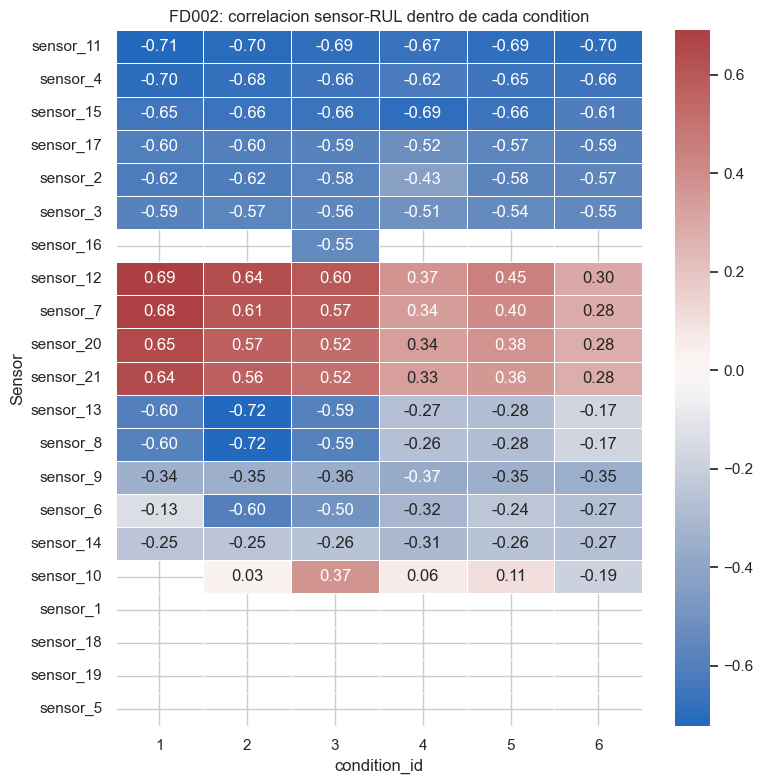

In [17]:
corr_heatmap = condition_corr.pivot(index="sensor", columns="condition_id", values="correlation")
ordered_sensors = corr_heatmap.abs().mean(axis=1).sort_values(ascending=False).index
corr_heatmap = corr_heatmap.loc[ordered_sensors]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_heatmap, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("FD002: correlacion sensor-RUL dentro de cada condition")
ax.set_xlabel("condition_id")
ax.set_ylabel("Sensor")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_sensor_rul_corr_by_condition_heatmap.png", dpi=150)
plt.show()


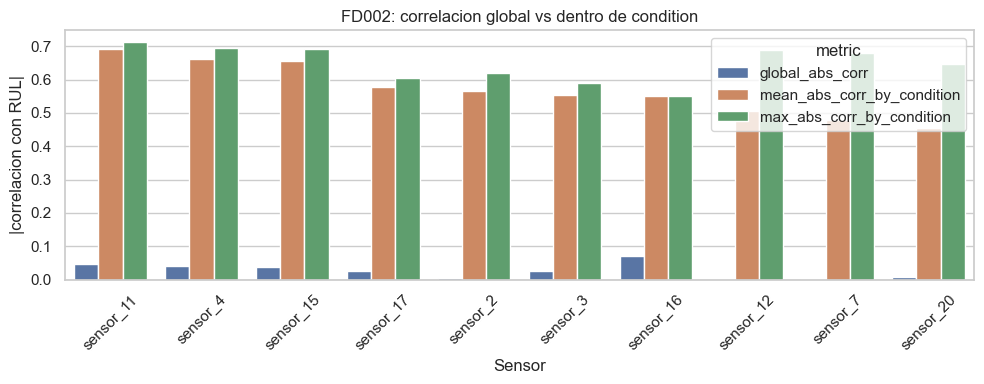

In [18]:
top_corr_compare = condition_corr_summary.sort_values("mean_abs_corr_by_condition", ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
plot_compare = top_corr_compare.melt(
    id_vars="sensor",
    value_vars=["global_abs_corr", "mean_abs_corr_by_condition", "max_abs_corr_by_condition"],
    var_name="metric",
    value_name="abs_corr",
)
sns.barplot(data=plot_compare, x="sensor", y="abs_corr", hue="metric", ax=ax)
ax.set_title("FD002: correlacion global vs dentro de condition")
ax.set_xlabel("Sensor")
ax.set_ylabel("|correlacion con RUL|")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_global_vs_condition_corr.png", dpi=150)
plt.show()


## 7. Normalizacion simple por condition

Como prueba rapida, se estandarizan sensores dentro de cada condition y se recalcula la correlacion global con RUL. Esto no reemplaza un pipeline de modelado, pero indica si normalizar por regimen puede recuperar senal.


In [19]:
train_cond_norm = train_cond.copy()
for sensor in SENSOR_COLUMNS:
    grouped = train_cond_norm.groupby("condition_id")[sensor]
    train_cond_norm[f"{sensor}_cond_z"] = (train_cond_norm[sensor] - grouped.transform("mean")) / grouped.transform("std")

condition_norm_cols = [f"{sensor}_cond_z" for sensor in SENSOR_COLUMNS]
condition_norm_corr = correlation_with_target(train_cond_norm, target="RUL", columns=condition_norm_cols)
condition_norm_corr.index = [index.replace("_cond_z", "") for index in condition_norm_corr.index]

norm_corr_compare = global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "raw_global_abs_corr"}).join(
    condition_norm_corr[["abs_correlation"]].rename(columns={"abs_correlation": "condition_z_abs_corr"})
)
norm_corr_compare["gain"] = norm_corr_compare["condition_z_abs_corr"] - norm_corr_compare["raw_global_abs_corr"]
norm_corr_compare.sort_values("gain", ascending=False).head(12)


,raw_global_abs_corr,condition_z_abs_corr,gain
sensor_11,0.0469,0.6936,0.6467
sensor_4,0.0410,0.6619,0.6209
sensor_15,0.0385,0.6504,0.6119
sensor_2,0.0049,0.5671,0.5621
sensor_17,0.0270,0.5793,0.5523
sensor_3,0.0269,0.5549,0.5279
sensor_12,0.0022,0.4860,0.4838
sensor_16,0.0714,0.5508,0.4795
sensor_7,0.0024,0.4607,0.4583
sensor_20,0.0063,0.4375,0.4312


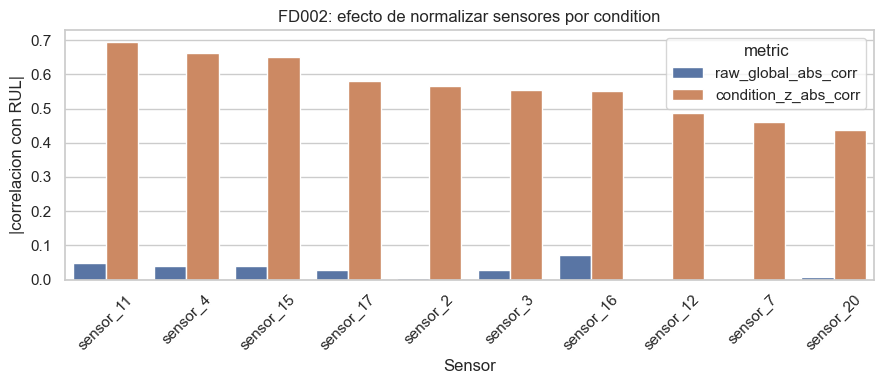

In [20]:
top_norm_compare = norm_corr_compare.sort_values("condition_z_abs_corr", ascending=False).head(10).reset_index().rename(columns={"index": "sensor"})
plot_norm = top_norm_compare.melt(
    id_vars="sensor",
    value_vars=["raw_global_abs_corr", "condition_z_abs_corr"],
    var_name="metric",
    value_name="abs_corr",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_norm, x="sensor", y="abs_corr", hue="metric", ax=ax)
ax.set_title("FD002: efecto de normalizar sensores por condition")
ax.set_xlabel("Sensor")
ax.set_ylabel("|correlacion con RUL|")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_normalized_corr.png", dpi=150)
plt.show()


## 8. Lectura final

- Los settings separan FD002 en seis conditions de forma muy clara. En la muestra usada para validar `k`, el silhouette de `k=6` es aproximadamente 0.997.
- Cada motor de train recorre las seis conditions. Por eso FD002 no es separable por motor-condition de forma simple: el regimen cambia dentro de las trayectorias.
- Train y test tienen proporciones muy parecidas por condition a nivel fila. La condition 6 aparece mas que las demas, cerca de 25% de las filas; las otras quedan alrededor de 15% cada una.
- Los sensores cambian mucho por condition. Los mas afectados por regimen son `sensor_11`, `sensor_15`, `sensor_8`, `sensor_18`, `sensor_9`, `sensor_14`, `sensor_3`, `sensor_17`, `sensor_4` y `sensor_5`.
- La correlacion global sensor-RUL subestima la senal. Por ejemplo, `sensor_11` tiene correlacion global absoluta cercana a 0.047, pero dentro de condition promedia aproximadamente 0.693.
- Al normalizar sensores por condition, reaparecen correlaciones fuertes con RUL: `sensor_11`, `sensor_4`, `sensor_15`, `sensor_2`, `sensor_17` y `sensor_3` pasan a ser claramente informativos.
- Para modelado FD002 conviene incluir `condition_id` o normalizar sensores por condition. Un baseline que ignore conditions seria metodologicamente debil.
- Como FD002 tiene un solo modo de falla, el foco no es separar fault modes sino separar regimen operativo de degradacion.
